# Regressao Linear - Atividade 01



---

**Machine Learning**

Tecnologia em Análise e Desenvolvimento de Sistemas

Instituto Federal de Mato Grosso do Sul - Câmpus Três Lagoas

Prof. Carlos R Santos Jr

1° Semestre de 2026

---



## Tarefa 01 - Leitura da base de dados

 Faça a leitura da base de dados **HousingData**.
 
 Link: https://raw.githubusercontent.com/CarlosR-SantosJr/DisciplinaInteligenciaArtificial-INTI6/main/datasets/HousingData.csv

Importação necessária: **Pandas**. 

In [166]:
import pandas as pd

In [167]:
url = 'https://raw.githubusercontent.com/CarlosR-SantosJr/DisciplinaInteligenciaArtificial-INTI6/main/datasets/HousingData.csv'

df = pd.read_csv(url)
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


descrição dada pelo professor:
**CRIM** - Taxa de crime per capita

**ZN** - Proporção de terrenos residenciais para lotes acima de 25.000 pés quadrados.

**INDUS** - Proporção de negócios não varejistas

**CHAS** - Variável dummy Charles River (= 1 se a área limita o rio; 0 caso contrário)

**NOX** - Concentração de óxidos nítricos  (partes por 10 milhões)

**RM** - Número médio de quartos por habitação 

**AGE** - Proporção de unidades ocupadas construídas antes de 1940

**DIS** - Distâncias ponderadas até cinco centros de empregos de Boston

**RAD** - Índice  de acessibilidade à rodovias radiais

**TAX** - Taxa de imposto sobre a propriedade (por 10.000 usd)

**PTRATIO** - Proporção aluno-professor por cidade

**LSTAT%** - Status inferior da população

**MEDV** - Valor médio das casas ocupadas ($1000s)

In [168]:
df.info() #retorna total de linhas, colunas, num d valores n nulos e o tipo de dado da coluna

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


## Tarefa 02 - Remoção de valores nulos (Missing Values)
Para sequência do projeto é necessário remover os valores nulos (missing values) da base de dados.

Importação necessária: **SimpleImputer** da biblioteca Scikit-learning

In [169]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

In [170]:
df.isnull().sum()

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

In [171]:
columns_ = df.columns
my_imputer = SimpleImputer()

In [172]:
df = pd.DataFrame(my_imputer.fit_transform(df), columns= columns_)

In [173]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


<Axes: >

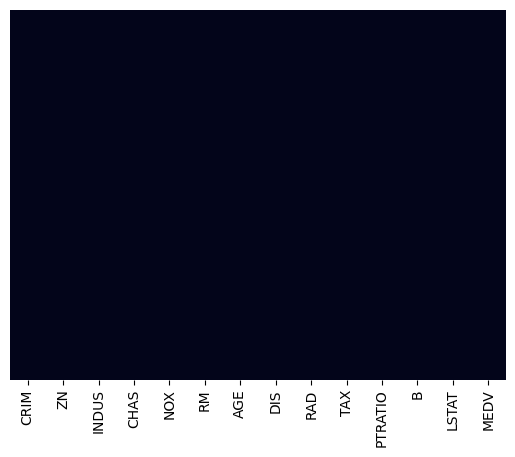

In [174]:
plt.Figure(figsize=(8,6))
sns.heatmap(df.isna(), cbar=False, yticklabels=False)

## Tarefa 03 - Divisão da base de dados (Treino/Teste)
Divida a base de dados e crie as varáveis necessárias para as fases de treino e teste: 
> **Treino:** X_treino e y_treino

> **Teste:** X_test e y_test

Importação necessária: **train_test_split** da biblioteca Scikit-learning


In [175]:
from sklearn.model_selection import train_test_split

gerar mapa de calor para fazer correlação entre as features

<Axes: >

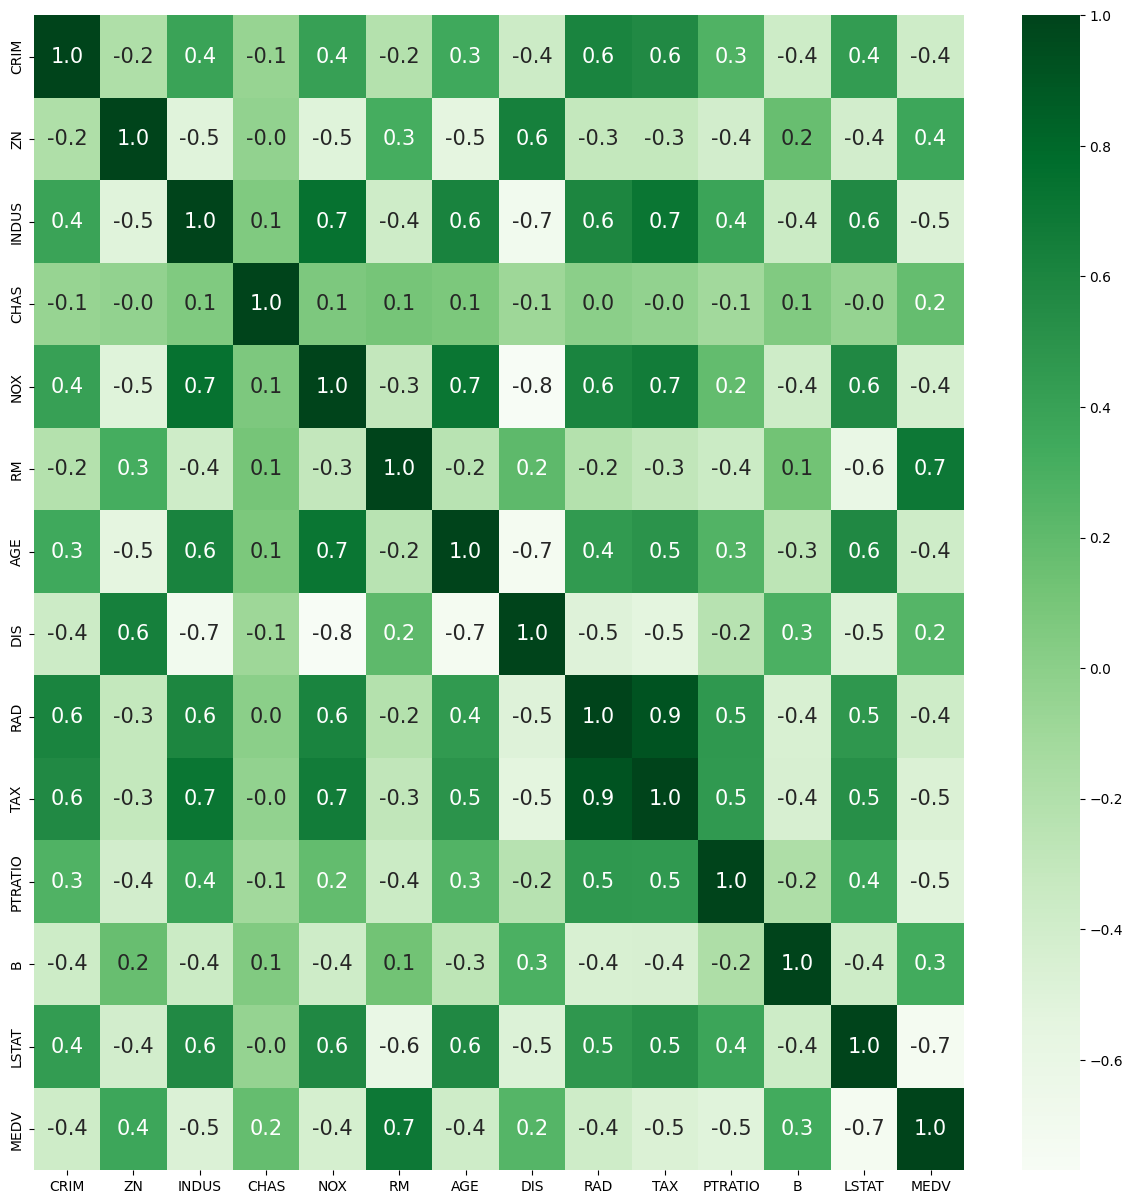

In [176]:
correlation = df.corr()
plt.figure(figsize=(15,15))
sns.heatmap(correlation, cbar=True, fmt='.1f', annot=True, annot_kws={'size':15}, cmap='Greens')

In [177]:
X = pd.DataFrame(df['MEDV']) #índice  de acessibilidade à rodovias radiais
y = pd.DataFrame(df['LSTAT']) #taxa de imposto sobre propriedade (por 10Kusd)

In [178]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state= 4)

## Tarefa 04 - Treino
Crie um modelo do tipo Regressão Linear e o treino utilizando as variáveis X_train e y_train. 

Importação necessária: **LinearRegression** da biblioteca Scikit-learning

In [179]:
from sklearn.linear_model import LinearRegression

In [180]:
linearModel = LinearRegression()
linearModel.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [181]:
print('A - intercepto: ', linearModel.intercept_)
print('B - inclinação: ', linearModel.coef_)

A - intercepto:  [25.72414961]
B - inclinação:  [[-0.58248907]]


## Tarefa 05 - Teste (Predição)
Agora, como o modelo treinado, faça a predição dos valores contidos na variável X_test e armazene as saídas na variável y_pred. 

In [182]:
y_pred = linearModel.predict(X_test)

## Tarefa 06 - Avaliação do Modelo
Avalie a eficiência do modelo preditivo através das métricas:
* Erro Médio Quadrático - MSE
* Raiz Quadrada do Erro Médio - RMSE
* Coeficiênte de Determinação - R^2 

Importação necessária: **mean_squared_error, r2_score e mean_squared_error** da biblioteca Scikit-learning

In [183]:
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt

In [184]:
print('MSE - mean squared error: %.2f' % mean_squared_error(y_test, y_pred))
print('RMSE - root mean squared error: %.2f' % sqrt(mean_squared_error(y_test, y_pred)))
print('R² - coefficient of determination: %.2f' % r2_score(y_test, y_pred))

MSE - mean squared error: 25.39
RMSE - root mean squared error: 5.04
R² - coefficient of determination: 0.50


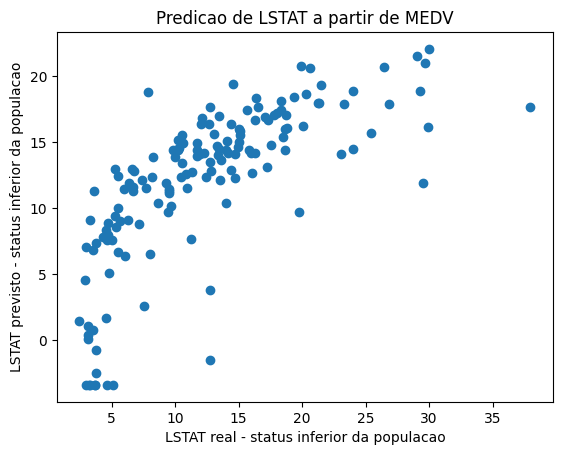

In [186]:
plt.scatter(y_test.values.ravel(), y_pred.ravel())
plt.xlabel('LSTAT real - status inferior da populacao')
plt.ylabel('LSTAT previsto - status inferior da populacao')
plt.title('Predicao de LSTAT a partir de MEDV')
plt.show()
